Carregando os dados...
Melhor valor de k encontrado: 8

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

      Empate       0.00      0.00      0.00         7
    O venceu       0.89      0.98      0.93        63
    Tem jogo       0.92      0.84      0.88       125
    X venceu       0.91      0.99      0.95       125

    accuracy                           0.91       320
   macro avg       0.68      0.70      0.69       320
weighted avg       0.89      0.91      0.90       320



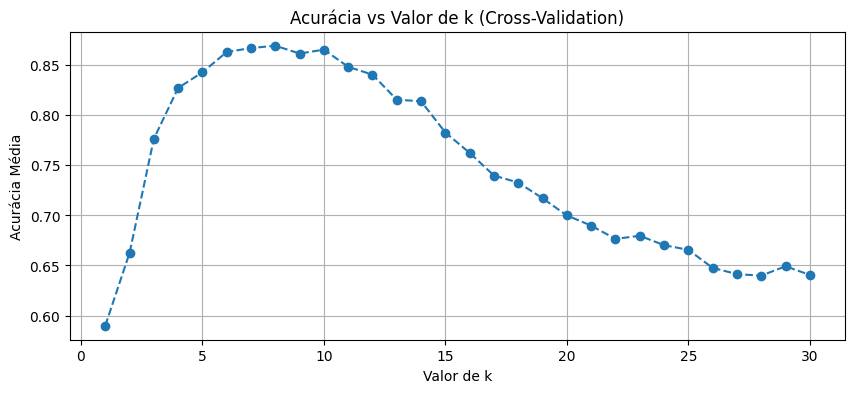

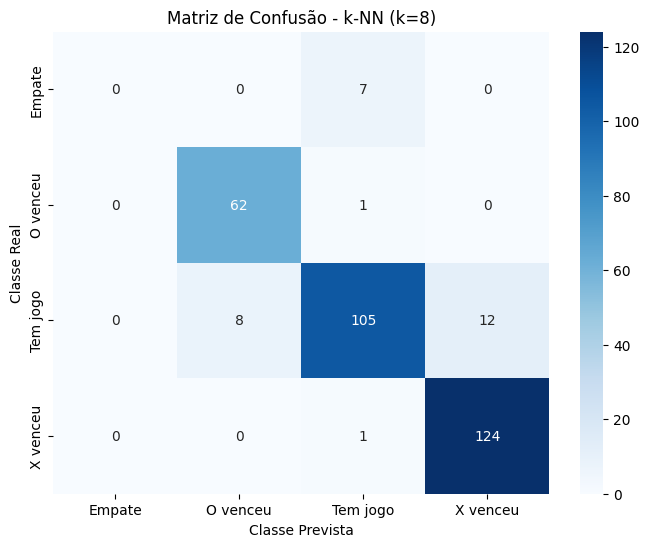

Sucesso! Modelo k-NN salvo em: ../../models/KNN


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# 1. Carregando os dados
print("Carregando os dados...")
df = pd.read_csv('../../data/processed/preprocessed_1.csv')
X = df.drop('classe', axis=1)
y = df['classe']

# 2. Encoding e Split
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 3. Busca do melhor K 
param_grid = {'n_neighbors': np.arange(1, 31)}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

melhor_k = grid_search.best_params_['n_neighbors']
print(f"Melhor valor de k encontrado: {melhor_k}")

# 4. Treinamento e Avaliação
knn_model = KNeighborsClassifier(n_neighbors=melhor_k)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

# --- Definindo as variáveis para evitar o NameError ---
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# 5. Relatórios
print("\n--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))

# 6. Gráfico de Acurácia vs K
plt.figure(figsize=(10, 4))
scores = grid_search.cv_results_['mean_test_score']
plt.plot(param_grid['n_neighbors'], scores, marker='o', linestyle='dashed')
plt.title('Acurácia vs Valor de k (Cross-Validation)')
plt.xlabel('Valor de k')
plt.ylabel('Acurácia Média')
plt.grid(True)
plt.show()

# 7. Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão - k-NN (k={melhor_k})')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

# 8. Exportação Automática para a Interface
import os
caminho_modelo = '../../models/KNN'
os.makedirs(caminho_modelo, exist_ok=True)

joblib.dump(knn_model, f'{caminho_modelo}/knn_model.pkl')
joblib.dump(le, f'{caminho_modelo}/knn_label_encoder.pkl')
print(f"Sucesso! Modelo k-NN salvo em: {caminho_modelo}")